# **Principal Component Analysis Without using Scikitlearn**


Real-world datasets often contain multiple features that are correlated with each other. Working with high-dimensional data can increase computational complexity and make visualization difficult. Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the original features into a new set of uncorrelated variables called Principal Components while preserving most of the information present in the data.

## Objective

The objective of this notebook is to implement PCA from scratch using NumPy without relying on machine learning libraries for the PCA algorithm itself. A synthetic housing dataset is generated containing features such as:

* Number of rooms
* Number of washrooms
* Location score
* House price

The implementation follows the standard PCA workflow:

1. Generate and load the dataset.
2. Standardize the features.
3. Compute the covariance matrix.
4. Calculate eigenvalues and eigenvectors.
5. Sort eigenvalues in descending order.
6. Select the top principal components.
7. Project the original data onto the new feature space.
8. Visualize the transformed data using a scatter plot.



In [8]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 5000

rooms = np.random.randint(1, 7, n)

washrooms = []
for r in rooms:
    washrooms.append(max(1, r // 2 + np.random.randint(0, 3)))

washrooms = np.array(washrooms)


location_score = np.random.randint(1, 13, n)

price_lakhs = (
     location_score * 8
    + washrooms * 5
    + np.random.normal(0, 10, n)
)

df = pd.DataFrame({
    "rooms": rooms,
    "washrooms": washrooms,
    "location_score": location_score,
    "price_lakhs": price_lakhs.round(2)
})

file_name = "housing_data.csv"

df.to_csv(file_name, index=False)

print(f"Saved as {file_name}")
from google.colab import files
files.download(file_name)

Saved as housing_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
df.head()

,rooms,washrooms,location_score,price_lakhs
0,4,4,10,104.54
1,5,2,8,66.30
2,3,3,3,23.25
3,5,2,8,69.93
4,5,2,6,69.09


<Axes: xlabel='rooms', ylabel='washrooms'>

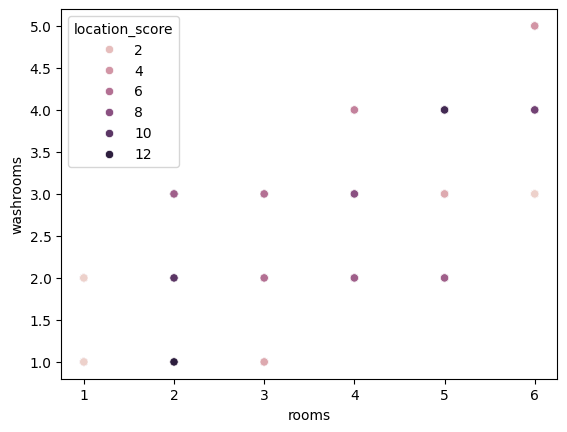

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.scatterplot(data=df,x='rooms',y='washrooms',hue='location_score')

In [15]:
room_mean=df['rooms'].mean()
w_mean=df['washrooms'].mean()
ls_mean=df['location_score'].mean()

In [16]:
# Centring the data around mean
df['rooms']=df['rooms']-room_mean
df['washrooms']=df['washrooms']-w_mean
df['location_score']=df['location_score']-ls_mean
df.head()

,rooms,washrooms,location_score,price_lakhs
0,0.5068,1.4422,3.4678,104.54
1,1.5068,-0.5578,1.4678,66.30
2,-0.4932,0.4422,-3.5322,23.25
3,1.5068,-0.5578,1.4678,69.93
4,1.5068,-0.5578,-0.5322,69.09


In [18]:
# Finding the covariance matrix
cov_mat=np.cov(np.array([df['rooms'],df['washrooms'],df['location_score']]))
cov_mat

array([[ 2.94174211,  1.449783  ,  0.09193735],
       [ 1.449783  ,  1.35332983,  0.01714227],
       [ 0.09193735,  0.01714227, 12.01816679]])

In [19]:
# Finding the eigen value and eigen vector of cov matrix
eigen_val,eigen_vec=np.linalg.eig(cov_mat)
print(eigen_val)
print(eigen_vec)

[ 0.49437838  3.79966533 12.01919502]
[[-0.50974609  0.86025941  0.01061459]
 [ 0.86032038  0.50974458  0.00304992]
 [ 0.00278701 -0.01068664  0.99993901]]


In [20]:
# Sort eigenvalues in descending order
i = np.argsort(eigen_val)[::-1]
eigen_val = eigen_val[i]
eigen_vec = eigen_vec[:, i]
print("Sorted Eigenvalues:")
print(eigen_val)
print("\nSorted Eigenvectors:")
print(eigen_vec)

Sorted Eigenvalues:
[12.01919502  3.79966533  0.49437838]

Sorted Eigenvectors:
[[ 0.01061459  0.86025941 -0.50974609]
 [ 0.00304992  0.50974458  0.86032038]
 [ 0.99993901 -0.01068664  0.00278701]]


In [21]:
w = eigen_vec[:, :2]

print("Projection Matrix:")
w

Projection Matrix:
[[ 0.01061459  0.86025941]
 [ 0.00304992  0.50974458]
 [ 0.99993901 -0.01068664]]


In [23]:
X_std = df[['rooms', 'washrooms', 'location_score']].values
X_pca = np.dot(X_std, w)

print("Transformed Data:")
print(X_pca[:5])

Transformed Data:
[[ 3.47736658  1.13407399]
 [ 1.4820033   0.99621751]
 [-3.53587102 -0.16112355]
 [ 1.4820033   0.99621751]
 [-0.51787472  1.01759078]]


In [24]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

In [25]:
pca_df.head()

,PC1,PC2
0,3.477367,1.134074
1,1.482003,0.996218
2,-3.535871,-0.161124
3,1.482003,0.996218
4,-0.517875,1.017591


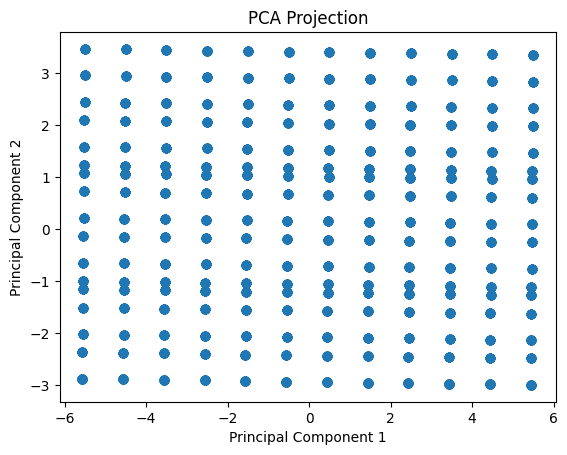

In [26]:
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection")
plt.show()

In [27]:
evr = eigen_val / np.sum(eigen_val)

print("Variance retained:",
      np.sum(evr[:2]) * 100)
# Hence, 96% of the information is retrieved

Variance retained: 96.96946519074166
